In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import bioframe as bf
import cooler
import matplotlib.pyplot as plt
import matplotlib as mpl
import cooltools
from tqdm import tqdm
import matplotlib
from coolpuppy import coolpup
from coolpuppy.lib.numutils import get_enrichment
from matplotlib import ticker
from matplotlib.colors import LogNorm
from matplotlib.ticker import EngFormatter
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from joblib import Memory
from itertools import product
cachedir = 'cache'
memory = Memory(cachedir, verbose=0)
eigs_cis_cache = memory.cache(cooltools.eigs_cis)
expected_cis_cache = memory.cache(cooltools.expected_cis, ignore=['nproc'])
expected_trans_cache = memory.cache(cooltools.expected_trans, ignore=['nproc'])
saddle_cache = memory.cache(cooltools.saddle)
coolpup_pileup_cache = memory.cache(coolpup.pileup)
cooltools_pileup_cashe = memory.cache(cooltools.pileup)


from statannotations.Annotator import Annotator

mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family='Helvetica', size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('fontTools').setLevel(logging.WARNING)

# Neurons

## Scaling

In [2]:
res_scal=10000

files = [i for i in os.listdir('../data/') if 'mcool' in i and 'plus' in i and 'merge' not in i]
files.sort()

exp_dict_sc = {}
for cl in files:
    
    name = cl.split('.')[0]
    print('start '+ name)
    clr_ = cooler.Cooler(f'../data/{cl}::/resolutions/{res_scal}')
    exp = expected_cis_cache(
                    clr=clr_,
                    smooth=True,
                    aggregate_smoothed=True,
                    nproc=16
                )
    
    exp_dict_sc[name] = exp

start HC-2Mplus
start HC-318plus
start HC-3Mplus
start HC-91plus
start HC24plus
start HCM12plus
start SZ-01plus
start SZ-03plus
start SZ08plus
start SZ10plus
start SZ20plus
start SZ6plus


In [3]:
der = {}

for name in exp_dict_sc.keys():
        
    exp_dict_sc[name] = exp_dict_sc[name][~exp_dict_sc[name]['region1'].isin(['chrX', 'chrY', 'chrM'])]
    exp_dict_sc[name] = exp_dict_sc[name][~exp_dict_sc[name]['region2'].isin(['chrX', 'chrY', 'chrM'])]
    
    exp_dict_sc[name].loc[:, 's_bp'] = exp_dict_sc[name]['dist'] * res_scal
    exp_dict_sc[name].loc[exp_dict_sc[name]['dist'] < 2, 'balanced.avg.smoothed.agg'] = np.nan
    exp_dict_sc[name].loc[:, 'balanced.avg.smoothed.agg.norm'] = exp_dict_sc[name]['balanced.avg.smoothed.agg'] / exp_dict_sc[name]['balanced.avg.smoothed.agg'].values[2]

    der[name] = np.gradient(np.log(exp_dict_sc[name]['balanced.avg.smoothed.agg.norm']),np.log(exp_dict_sc[name]['s_bp']))

exp_dict_sc

/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in add
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1310: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1311: RuntimeWarning: invalid value encountered in add
  c = dx1 / (dx2 * (dx1 + dx2))
/home/adudkovskaya/.conda/envs/hic/lib/python3.13/site-

{'HC-2Mplus':        region1 region2  dist   dist_bp  contact_frequency  n_total  n_valid  \
 0         chr1    chr1     0         0                NaN    24896    21157   
 1         chr1    chr1     1     10000           0.000182    24895    20896   
 2         chr1    chr1     2     20000           0.015977    24894    20852   
 3         chr1    chr1     3     30000           0.011413    24893    20819   
 4         chr1    chr1     4     40000           0.008903    24892    20782   
 ...        ...     ...   ...       ...                ...      ...      ...   
 287504   chr22   chr22  5077  50770000           0.000012        5        0   
 287505   chr22   chr22  5078  50780000           0.000012        4        0   
 287506   chr22   chr22  5079  50790000           0.000012        3        0   
 287507   chr22   chr22  5080  50800000           0.000012        2        0   
 287508   chr22   chr22  5081  50810000           0.000012        1        0   
 
         count.sum  balan

In [4]:
exp_dict_sc['HC-2Mplus']

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg,s_bp,balanced.avg.smoothed.agg.norm
0,chr1,chr1,0,0,NaN,24896,21157,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,chr1,chr1,1,10000,0.000182,24895,20896,NaN,NaN,NaN,NaN,0.000189,NaN,10000,NaN
2,chr1,chr1,2,20000,0.015977,24894,20852,156652.0,370.470133,6.292761,0.017767,0.016583,0.015977,20000,1.000000
3,chr1,chr1,3,30000,0.011413,24893,20819,107342.0,254.237973,4.312136,0.012212,0.011940,0.011413,30000,0.714307
4,chr1,chr1,4,40000,0.008903,24892,20782,83706.0,197.678982,3.362767,0.009512,0.009343,0.008903,40000,0.557263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287504,chr22,chr22,5077,50770000,0.000012,5,0,0.0,0.000000,0.000000,NaN,0.000037,0.000012,50770000,0.000738
287505,chr22,chr22,5078,50780000,0.000012,4,0,0.0,0.000000,0.000000,NaN,0.000037,0.000012,50780000,0.000738
287506,chr22,chr22,5079,50790000,0.000012,3,0,0.0,0.000000,0.000000,NaN,0.000037,0.000012,50790000,0.000737
287507,chr22,chr22,5080,50800000,0.000012,2,0,0.0,0.000000,0.000000,NaN,0.000037,0.000012,50800000,0.000737


In [5]:
list(exp_dict_sc.keys())[1:]

['HC-318plus',
 'HC-3Mplus',
 'HC-91plus',
 'HC24plus',
 'HCM12plus',
 'SZ-01plus',
 'SZ-03plus',
 'SZ08plus',
 'SZ10plus',
 'SZ20plus',
 'SZ6plus']

In [6]:
scaling_df = exp_dict_sc['HC-2Mplus'][['s_bp', 'balanced.avg.smoothed.agg.norm']]
scaling_df = scaling_df.rename(columns={'balanced.avg.smoothed.agg.norm':'HC-2Mplus'})
for name in list(exp_dict_sc.keys())[1:]:
    print(name)
    scaling_df = pd.concat([scaling_df, exp_dict_sc[name][['balanced.avg.smoothed.agg.norm']]], axis = 1)#, left_on = 's_bp', right_on = 's_bp')
    scaling_df = scaling_df.rename(columns={'balanced.avg.smoothed.agg.norm':name})

scaling_df

HC-318plus
HC-3Mplus
HC-91plus
HC24plus
HCM12plus
SZ-01plus
SZ-03plus
SZ08plus
SZ10plus
SZ20plus
SZ6plus


,s_bp,HC-2Mplus,HC-318plus,HC-3Mplus,HC-91plus,HC24plus,HCM12plus,SZ-01plus,SZ-03plus,SZ08plus,SZ10plus,SZ20plus,SZ6plus
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,30000,0.714307,0.784677,0.727221,0.748780,0.715167,0.702947,0.732061,0.762971,0.720545,0.735775,0.732787,0.721171
4,40000,0.557263,0.653784,0.576278,0.601390,0.553887,0.539464,0.580753,0.622878,0.564069,0.584779,0.582929,0.564623
...,...,...,...,...,...,...,...,...,...,...,...,...,...
287504,50770000,0.000738,0.001599,0.000807,0.001104,0.000899,0.000540,0.000791,0.001060,0.000899,0.000828,0.000695,0.000837
287505,50780000,0.000738,0.001599,0.000807,0.001104,0.000899,0.000540,0.000791,0.001060,0.000899,0.000828,0.000695,0.000836
287506,50790000,0.000737,0.001598,0.000806,0.001104,0.000899,0.000540,0.000791,0.001060,0.000899,0.000828,0.000695,0.000836
287507,50800000,0.000737,0.001598,0.000806,0.001104,0.000899,0.000540,0.000791,0.001059,0.000899,0.000828,0.000695,0.000836


In [7]:
scaling_df_mean = scaling_df[['s_bp']]
scaling_df_mean['HC'] = np.mean(scaling_df[['HCM12plus', 'HC-3Mplus', 'HC24plus', 'HC-318plus', 'HC-91plus', 'HC-2Mplus']], axis = 1)
scaling_df_mean['SZ'] = np.mean(scaling_df[['SZ-01plus', 'SZ20plus', 'SZ10plus', 'SZ08plus', 'SZ-03plus', 'SZ6plus']], axis = 1)
scaling_df_mean = scaling_df_mean[['s_bp', 'HC', 'SZ']]
df_scal = pd.concat([scaling_df_mean[['s_bp', 'HC']], scaling_df_mean[['s_bp', 'HC']]], axis = 0)
df_scal[''] = ['HC']*len(scaling_df_mean) + ['SZ']*len(scaling_df_mean)
df_scal.columns = ['s_bp', 'Contact frequency', '']
df_scal = df_scal.dropna()
df_scal = df_scal.reset_index(drop=True)
df_scal

/tmp/ipykernel_3101162/3008396975.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC'] = np.mean(scaling_df[['HCM12plus', 'HC-3Mplus', 'HC24plus', 'HC-318plus', 'HC-91plus', 'HC-2Mplus']], axis = 1)
/tmp/ipykernel_3101162/3008396975.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['SZ'] = np.mean(scaling_df[['SZ-01plus', 'SZ20plus', 'SZ10plus', 'SZ08plus', 'SZ-03plus', 'SZ6plus']], axis = 1)


,s_bp,Contact frequency,
0,20000,1.000000,HC
1,30000,0.732183,HC
2,40000,0.580344,HC
3,50000,0.489605,HC
4,60000,0.429338,HC
...,...,...,...
574925,50770000,0.000948,SZ
574926,50780000,0.000948,SZ
574927,50790000,0.000947,SZ
574928,50800000,0.000947,SZ


/tmp/ipykernel_2179406/4274556416.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


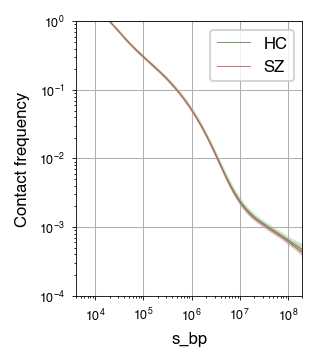

In [41]:
df_scal = pd.DataFrame(pd.concat([scaling_df['HCM12plus'], scaling_df['HC-3Mplus'], scaling_df['HC24plus'], 
                                  scaling_df['HC-318plus'], scaling_df['HC-91plus'], scaling_df['HC-2Mplus'],
                                  scaling_df['SZ-01plus'], scaling_df['SZ20plus'], scaling_df['SZ10plus'], 
                                  scaling_df['SZ08plus'], scaling_df['SZ-03plus'], scaling_df['SZ6plus']], axis = 0))

df_scal['s_bp'] = list(scaling_df['s_bp']) * 12
df_scal[''] = ['HC']*len(scaling_df)*6 + ['SZ']*len(scaling_df)*6
df_scal.columns = ['Contact frequency', 's_bp', '']
df_scal = df_scal.reset_index(drop=True)
#df_scal = df_scal.iloc[:400000]
res_scal=5000

# Plot scaling
f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(2, 2.3), 
                  layout="constrained")



groups_colors = {'HC': '#4e893f',
                 'SZ': '#c35959'}

i,k = -0.05,-0.05

#plt.plot([3e6, 3e6], [0, 2], 'k--', alpha=0.3)

plt.xlim([4000, 2e8])
plt.ylim([1e-4, 1])
#plt.adjustable("box")
#plt.aspect(1)
plt.grid(lw=0.5)
plt.ylabel('Contact frequency')
plt.legend()
plt.xscale('log')
plt.yscale('log')

sns.lineplot(df_scal, x = 's_bp', y = 'Contact frequency', hue = '', palette = groups_colors)


#plt.tight_layout()    
    
plt.savefig('picture_results/Scaling_all_neuron.svg',bbox_inches='tight')

/tmp/ipykernel_2844401/1711810791.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC young'] = np.mean(scaling_df[['HCM12plus', 'HC-3Mplus']], axis = 1)
/tmp/ipykernel_2844401/1711810791.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC old'] = np.mean(scaling_df[['HC24plus', 'HC-318plus', 'HC-91plus', 'HC-2Mplus']], axis = 1)
/tmp/ipykernel_2844401/1711810791.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

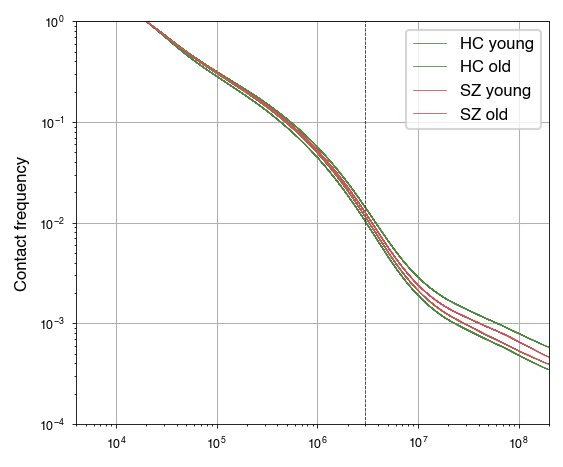

In [12]:
scaling_df_mean = scaling_df[['s_bp']]
scaling_df_mean['HC young'] = np.mean(scaling_df[['HCM12plus', 'HC-3Mplus']], axis = 1)
scaling_df_mean['HC old'] = np.mean(scaling_df[['HC24plus', 'HC-318plus', 'HC-91plus', 'HC-2Mplus']], axis = 1)
scaling_df_mean['SZ young'] = np.mean(scaling_df[['SZ-01plus', 'SZ20plus']], axis = 1)
scaling_df_mean['SZ old'] = np.mean(scaling_df[['SZ10plus', 'SZ08plus', 'SZ-03plus', 'SZ6plus']], axis = 1)
scaling_df_mean = scaling_df_mean[['s_bp', 'HC young', 'HC old', 'SZ young', 'SZ old']]
res_scal=5000

# Plot scaling
f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(4, 3), 
                  layout="constrained")


groups_colors = {'HC young': '#4e893f',
                 'HC old': '#4e893f',
                 'SZ young': '#c35959',
                 'SZ old': '#c35959'}

i,k = -0.05,-0.05
for name in scaling_df_mean.columns[1:]:
        
    ax = axs
    ax.plot([3e6, 3e6], [1e-4, 1], 'k--', alpha=0.3)
    ax.loglog(
        scaling_df_mean['s_bp'],
        scaling_df_mean[name], c=groups_colors[name], #alpha = dd,
        label=name)


    ax.set(
        ylabel='Contact frequency')

    ax.set_xlim([4000, 2e8])
    ax.set_ylim([1e-4, 1])
    ax.set_adjustable("box")
    ax.set_aspect(1)
    ax.grid(lw=0.5)
    ax.legend()

    #plt.savefig(f'/home/kmorozov/figs/scalings_age_effect/{reg} {ctype}.png',dpi=100,bbox_inches='tight')

In [9]:
scaling_df_mean = scaling_df[['s_bp']]
scaling_df_mean['HC young'] = np.mean(scaling_df[['HCM12plus', 'HC-3Mplus']], axis = 1)
scaling_df_mean['HC old'] = np.mean(scaling_df[['HC24plus', 'HC-318plus', 'HC-91plus', 'HC-2Mplus']], axis = 1)
scaling_df_mean['SZ young'] = np.mean(scaling_df[['SZ-01plus', 'SZ20plus']], axis = 1)
scaling_df_mean['SZ old'] = np.mean(scaling_df[['SZ10plus', 'SZ08plus', 'SZ-03plus', 'SZ6plus']], axis = 1)
scaling_df_mean['HC o/y'] = scaling_df_mean['HC old']/scaling_df_mean['HC young']
scaling_df_mean['SZ o/y'] = scaling_df_mean['SZ old']/scaling_df_mean['SZ young']
scaling_df_mean = scaling_df_mean[['s_bp', 'HC o/y', 'SZ o/y']]
scaling_df_mean = scaling_df_mean.dropna()
scaling_df_mean

/tmp/ipykernel_3101162/206045527.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC young'] = np.mean(scaling_df[['HCM12plus', 'HC-3Mplus']], axis = 1)
/tmp/ipykernel_3101162/206045527.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean['HC old'] = np.mean(scaling_df[['HC24plus', 'HC-318plus', 'HC-91plus', 'HC-2Mplus']], axis = 1)
/tmp/ipykernel_3101162/206045527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

,s_bp,HC o/y,SZ o/y
2,20000,1.000000,1.000000
3,30000,1.035868,1.003675
4,40000,1.060426,1.003861
5,50000,1.075633,1.003606
6,60000,1.086891,1.003683
...,...,...,...
287504,50770000,1.611348,1.219219
287505,50780000,1.611356,1.219233
287506,50790000,1.611363,1.219247
287507,50800000,1.611371,1.219261


In [10]:
scaling_df_mean = scaling_df_mean.drop_duplicates()

In [ ]:
mpl.rc('lines', linewidth=1)
mpl.rc('font', family='Helvetica', size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

res_scal=5000

# Plot scaling
f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(3, 2.4), 
                  layout="constrained")


groups_colors = {'HC o/y': '#4e893f',
                 'SZ o/y': '#c35959'}

i,k = -0.05,-0.05
for name in scaling_df_mean.columns[1:]:
        
    ax = axs
    ax.plot([3e6, 3e6], [1e-4, 1], 'k--', alpha=0.3)
    ax.plot(
        scaling_df_mean['s_bp'],
        scaling_df_mean[name], c=groups_colors[name], #alpha = dd,
        label=name)


    ax.set(
        ylabel='Contact frequency')

    ax.set_xlim([4000, 2e8])
    ax.set_ylim([1, 2])
    ax.set_adjustable("box")
    #ax.set_aspect(1)
    ax.grid(lw=0.5, axis='both')
    ax.legend()
    ax.set_xscale('log')

plt.tight_layout()

plt.savefig('picture_results/Scaling_neuron.svg',bbox_inches='tight')

In [11]:
scaling_df_mean_var = scaling_df[['s_bp']]

for hc_o in ['HC24plus', 'HC-318plus', 'HC-91plus', 'HC-2Mplus']:
    for hc_y in ['HCM12plus', 'HC-3Mplus']:
        scaling_df_mean_var[f'{hc_o}/{hc_y}'] = scaling_df[hc_o]/scaling_df[hc_y]

for sz_o in ['SZ10plus', 'SZ08plus', 'SZ-03plus', 'SZ6plus']:
    for sz_y in ['SZ-01plus', 'SZ20plus']:
        scaling_df_mean_var[f'{sz_o}/{sz_y}'] = scaling_df[sz_o]/scaling_df[sz_y]

df_scal_var = pd.DataFrame()

for col in scaling_df_mean_var.columns[1:]:
    df = pd.DataFrame()
    df['s_bp'] = scaling_df_mean_var['s_bp']
    if 'HC' in col:
        df['data'] = scaling_df_mean_var[col]
        df[''] = 'HC o/y'
    elif 'SZ' in col:
        df['data'] = scaling_df_mean_var[col]
        df[''] = 'SZ o/y'
    df_scal_var = pd.concat([df_scal_var, df])

df_scal_var = df_scal_var.dropna()
df_scal_var

/tmp/ipykernel_3101162/3009875482.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean_var[f'{hc_o}/{hc_y}'] = scaling_df[hc_o]/scaling_df[hc_y]
/tmp/ipykernel_3101162/3009875482.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaling_df_mean_var[f'{hc_o}/{hc_y}'] = scaling_df[hc_o]/scaling_df[hc_y]
/tmp/ipykernel_3101162/3009875482.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

,s_bp,data,
2,20000,1.000000,HC o/y
3,30000,1.017383,HC o/y
4,40000,1.026737,HC o/y
5,50000,1.030725,HC o/y
6,60000,1.034183,HC o/y
...,...,...,...
287504,50770000,1.203860,SZ o/y
287505,50780000,1.203848,SZ o/y
287506,50790000,1.203836,SZ o/y
287507,50800000,1.203823,SZ o/y


/tmp/ipykernel_3101162/2968634933.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


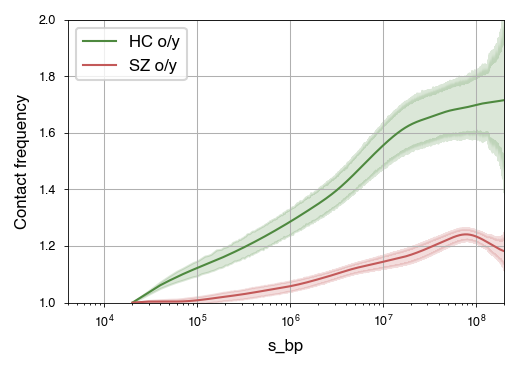

In [15]:
mpl.rc('lines', linewidth=1)
mpl.rc('font', family='Helvetica', size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400


# Plot scaling

plt.figure(figsize=(3.5, 2.5), dpi=150)


groups_colors = {'HC o/y': '#4e893f',
                 'SZ o/y': '#c35959'}

i,k = -0.05,-0.05

#plt.plot([3e6, 3e6], [0, 2], 'k--', alpha=0.3)


plt.ylabel('Contact frequency')

plt.xlim([4000, 2e8])
plt.ylim([1, 2])
#plt.adjustable("box")
#plt.aspect(1)
plt.grid(lw=0.5, axis='both')
plt.legend()
plt.xscale('log')

sns.lineplot(df_scal_var, x = 's_bp', y = 'data', hue = '', palette = groups_colors)


    

plt.tight_layout()

plt.savefig('picture_results/Scaling_var_neuron.svg',bbox_inches='tight')

## ICF

100%|██████████| 12/12 [05:25<00:00, 27.12s/it]


Text(0, 0.5, 'ICF')

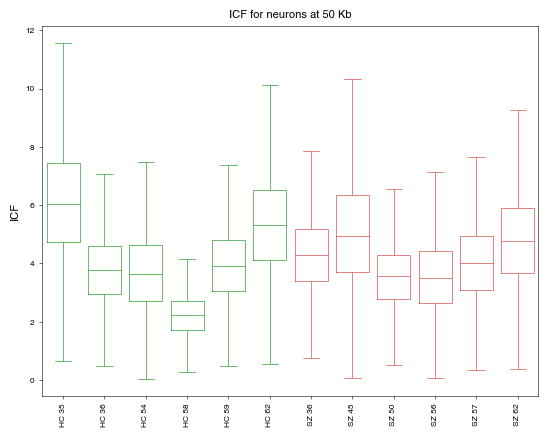

In [6]:
ages = {
    'HC-2Mplus':'HC 62 2M',
    'HC-2Mminus':'HC 62 2M',
    'HC-3Mplus':'HC 36 3M',
    'HC-3Mminus':'HC 36 3M',
    'HC-318plus':'HC 58 318',
    'HC-91plus':'HC 59 91',
    'HC-91minus':'HC 59 91',
    'HC24plus':'HC 54 24',
    'HC24minus':'HC 54 24',
    'HCM12plus':'HC 35 12M',
    'HCM12minus':'HC 35 12M',
    'SZ-01plus':'SZ 36 01',
    'SZ-01minus':'SZ 36 01',
    'SZ-03plus':'SZ 57 03',
    'SZ-03minus':'SZ 57 03',
    'SZ08plus':'SZ 56 08',
    'SZ08minus':'SZ 56 08',
    'SZ10plus':'SZ 50 10',
    'SZ10minus':'SZ 50 10',
    'SZ20plus':'SZ 45 20',
    'SZ20minus':'SZ 45 20',
    'SZ6plus':'SZ 62 06',
    'SZ6minus':'SZ 62 06'
}

# compute expected
cvd = {'HC': {'NeuN+': {}, 'NeuN-': {}}, 
       'SZ': {'NeuN+': {}, 'NeuN-': {}}}

res = 50_000

clr_dir = '../data/'
clr_names = {
            'HC-2Mplus': 'HC-2Mplus.sampled.drop_diag.1kb.mcool',
            'HC24plus': 'HC24plus.sampled.drop_diag.1kb.mcool',
            'HC-91plus': 'HC-91plus.sampled.drop_diag.1kb.mcool',
            'HC-318plus': 'HC-318plus.sampled.drop_diag.1kb.mcool',
            'HCM12plus': 'HCM12plus.sampled.drop_diag.1kb.mcool',
            'HC-3Mplus': 'HC-3Mplus.sampled.drop_diag.1kb.mcool',

            'SZ-01plus': 'SZ-01plus.sampled.drop_diag.1kb.mcool',
            'SZ-03plus': 'SZ-03plus.sampled.drop_diag.1kb.mcool',
            'SZ6plus': 'SZ6plus.sampled.drop_diag.1kb.mcool',
            'SZ08plus': 'SZ08plus.sampled.drop_diag.1kb.mcool',
            'SZ10plus': 'SZ10plus.sampled.drop_diag.1kb.mcool',
            'SZ20plus': 'SZ20plus.sampled.drop_diag.1kb.mcool',
}


clrs = {name: cooler.Cooler(clr_dir + clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}

chroms = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6',
 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14',
 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']


def compute_ICF(hiclist, dropdiag=0, resolution=50000, stable=True, normalized=False):
    """
    This function returns a dictionary where keys are names of Hi-C matrices
    and values are matrices of cis-trans contact sums.
    
    hiclist :: [str] - list of paths to .mcool files
    dropdiag :: int - number of diags to drop (main diagonal counts from 1)
    resolution :: int - desired resolution for Hi-C matrix
    stable :: bool - whether to add 1 to contact sums matrix (for numerical 
                     stability at logarithm computation)
    normalized :: bool - whether to normalize matrix with a total sum of contacts
    """

    icf={}

    for path in tqdm(hiclist):
        
        clr = cooler.Cooler(path + '::/resolutions/%d' % resolution)
        f = path.split('/')[-1].split('.')[0]
        name = ages[f]
        bins = pd.DataFrame(clr.bins()[:].drop(columns=['start', 'end']))
        #bins = bins[bins['chrom'].isin(chroms)]
        pix = clr.pixels()[:]
        pix_no_diag = pix[pix.bin2_id >= pix.bin1_id + dropdiag]
        pix_no_diag = pd.DataFrame(pix_no_diag.merge(bins, left_on='bin1_id', right_index=True).\
                                merge(bins, left_on='bin2_id', right_index=True))
        m = pix_no_diag[(pix_no_diag['chrom_x'].isin(chroms))&(pix_no_diag['chrom_y'].isin(chroms))]
        m_diag = m[(m['chrom_x'] == m['chrom_y'])]
        m_nediag = m[(m['chrom_x'] != m['chrom_y'])]
        x_diag = m_diag.groupby('bin1_id')['count'].sum()
        y_diag = m_diag.groupby('bin2_id')['count'].sum()
        x_nediag = m_nediag.groupby('bin1_id')['count'].sum()
        y_nediag = m_nediag.groupby('bin2_id')['count'].sum()
        diag = pd.DataFrame(pd.merge(x_diag, y_diag, left_index=True, right_index=True))
        diag['sum_inter'] = diag['count_x']+diag['count_y']
        nediag = pd.DataFrame(pd.merge(x_nediag, y_nediag, left_index=True, right_index=True))
        nediag['sum_intra'] = nediag['count_x']+nediag['count_y']
        final_df = pd.DataFrame(pd.merge(diag, nediag, left_index=True, right_index=True))
        final_df['ICF'] = final_df['sum_inter']/final_df['sum_intra']
        final_df = final_df.reset_index()

        icf[name]=final_df[['index', 'ICF']]

    return icf

phenotypes = [['HC-2Mplus', 'HC_plus_old', 'old', 'HC'],
                ['HC24plus', 'HC_plus_old', 'old', 'HC'],
                ['HC-91plus', 'HC_plus_old', 'old', 'HC'],
                ['HC-318plus', 'HC_plus_old', 'old', 'HC'],
                ['HCM12plus', 'HC_plus_young', 'young', 'HC'],
                ['HC-3Mplus', 'HC_plus_young', 'young', 'HC'],
                ['SZ-01plus', 'SZ_plus_young', 'young', 'SZ'],
                ['SZ20plus', 'SZ_plus_young', 'young', 'SZ'],
                ['SZ-03plus', 'SZ_plus_old', 'old', 'SZ'],
                ['SZ6plus', 'SZ_plus_old', 'old', 'SZ'],
                ['SZ08plus', 'SZ_plus_old', 'old', 'SZ'],
                ['SZ10plus', 'SZ_plus_old', 'old', 'SZ'],
             ]

lst = ['../data/' + clr_names[phen[0]] for phen in phenotypes]
icf = compute_ICF(lst, dropdiag=0, resolution=50000, stable=True, normalized=False)

dic_icf = icf[list(icf.keys())[0]]
dic_icf.columns = ['index', list(icf.keys())[0]]
for i in list(icf.keys())[1:]:
    a = icf[i]
    a.columns = ['index', i]
    dic_icf = pd.merge(dic_icf, icf[i], left_on = 'index', right_on='index')

dic_icf = dic_icf.drop(columns = ['index'])
dic_icf = dic_icf.dropna()
dic_icf

sns.boxplot(dic_icf,showfliers=False, order = ['HC 35 12M', 'HC 36 3M', 'HC 54 24', 'HC 58 318', 'HC 59 91',
 'HC 62 2M', 'SZ 36 01', 'SZ 45 20', 'SZ 50 10', 'SZ 56 08', 'SZ 57 03', 'SZ 62 06'],palette=['green','green','green','green','green','green',
                                                                                           '#CD2626','#CD2626','#CD2626',
                                                                                           '#CD2626','#CD2626','#CD2626'],
           fill=False)
plt.xticks(['HC 35 12M', 'HC 36 3M', 'HC 54 24', 'HC 58 318', 'HC 59 91',
 'HC 62 2M', 'SZ 36 01', 'SZ 45 20', 'SZ 50 10', 'SZ 56 08', 'SZ 57 03', 'SZ 62 06'],['HC 35', 'HC 36', 'HC 54', 'HC 58', 'HC 59',
 'HC 62', 'SZ 36', 'SZ 45', 'SZ 50', 'SZ 56', 'SZ 57', 'SZ 62'],rotation=90)
plt.title('ICF for neurons at 50 Kb')
plt.ylabel('ICF')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=1.382e+12


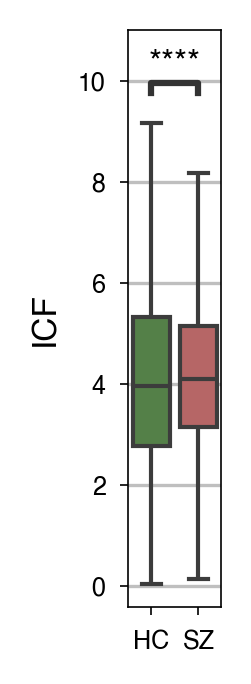

In [8]:

name_dict = {'HC 35 12M': 'HC', 'HC 36 3M': 'HC', 'HC 54 24': 'HC', 'HC 58 318': 'HC', 'HC 59 91': 'HC', 'HC 62 2M': 'HC', 
 'SZ 36 01': 'SZ', 'SZ 45 20': 'SZ', 'SZ 50 10': 'SZ', 'SZ 56 08': 'SZ', 'SZ 57 03': 'SZ', 'SZ 62 06': 'SZ'}
icf_hcsz = dic_icf.rename(columns = name_dict)



f, axs = plt.subplots(
    figsize=(0.4,2.5),
    ncols=1,
    nrows=1, dpi = 300)

groups_colors = {'HC': '#4e893f',
                 'SZ': '#c35959'}
plt.ylabel('ICF')
boxplot = sns.boxplot(icf_hcsz, palette = groups_colors, showfliers=False, order = ['HC','SZ'])
axs.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
pairs = [('HC', 'SZ')]

annotator = Annotator(boxplot, pairs, data=icf_hcsz)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.savefig('picture_results/ICF_all_neuron.svg',bbox_inches='tight')


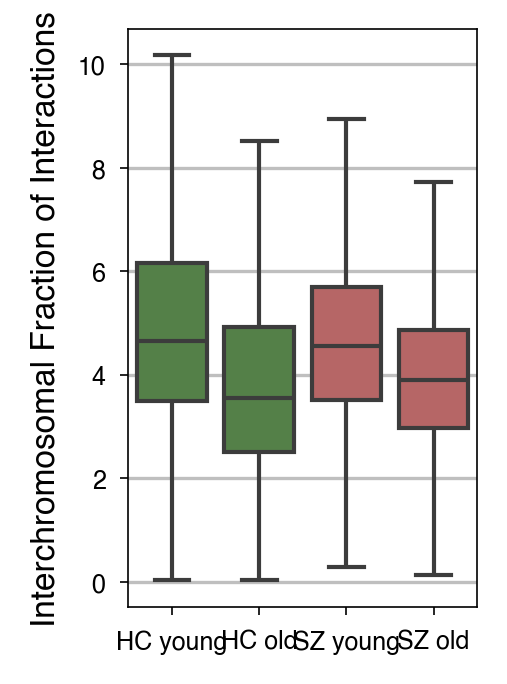

In [10]:

name_dict = {'HC 35 12M': 'HC young', 'HC 36 3M': 'HC young', 'HC 54 24': 'HC old', 'HC 58 318': 'HC old', 'HC 59 91': 'HC old', 'HC 62 2M': 'HC old', 
 'SZ 36 01': 'SZ young', 'SZ 45 20': 'SZ young', 'SZ 50 10': 'SZ old', 'SZ 56 08': 'SZ old', 'SZ 57 03': 'SZ old', 'SZ 62 06': 'SZ old'}
icf_youngold = dic_icf.rename(columns = name_dict)





f, axs = plt.subplots(
    figsize=(1.5, 2.5),
    ncols=1,
    nrows=1, dpi = 300)

groups_colors = {'HC young': '#4e893f',
                 'HC old': '#4e893f',
                 'SZ young': '#c35959',
                 'SZ old': '#c35959'}

boxplot = sns.boxplot(icf_youngold, palette = groups_colors, showfliers=False, order = ['HC young', 'HC old', 'SZ young', 'SZ old'])
axs.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
pairs = [('HC young', 'HC old'), ('SZ young', 'SZ old')]
plt.ylabel('Interchromosomal Fraction of Interactions')
#annotator = Annotator(boxplot, pairs, data=dlr_youngold)
#annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
#annotator.apply_and_annotate()
plt.savefig('picture_results/ICF_aging_neuron_all.svg',bbox_inches='tight')



p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC
o/y vs. SZ
o/y: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=3.334e+08


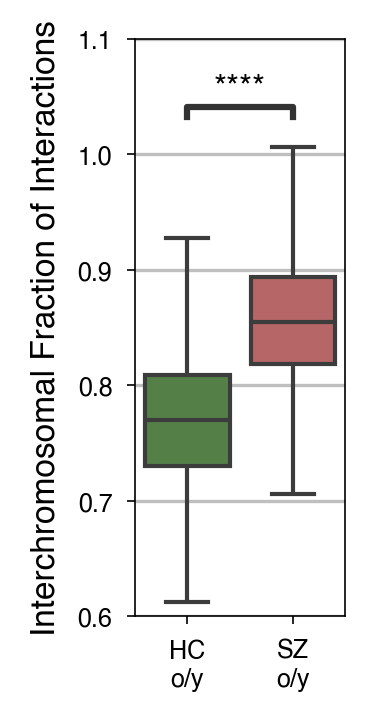

In [11]:
dic_icf_mean = pd.DataFrame()
dic_icf_mean['HC young'] = np.mean(dic_icf[['HC 35 12M', 'HC 36 3M']], axis = 1)
dic_icf_mean['HC old'] = np.mean(dic_icf[['HC 54 24', 'HC 58 318', 'HC 59 91', 'HC 62 2M']], axis = 1)
dic_icf_mean['SZ young'] = np.mean(dic_icf[['SZ 36 01', 'SZ 45 20']], axis = 1)
dic_icf_mean['SZ old'] = np.mean(dic_icf[['SZ 50 10', 'SZ 56 08', 'SZ 57 03', 'SZ 62 06']], axis = 1)
dic_icf_mean['HC\no/y'] = dic_icf_mean['HC old']/dic_icf_mean['HC young']
dic_icf_mean['SZ\no/y'] = dic_icf_mean['SZ old']/dic_icf_mean['SZ young']
dic_icf_mean = dic_icf_mean[['HC\no/y', 'SZ\no/y']]
dic_icf_mean

f, axs = plt.subplots(
    figsize=(0.9, 2.5),
    ncols=1,
    nrows=1, dpi = 300)

groups_colors = {'HC\no/y': '#4e893f',
                 'SZ\no/y': '#c35959'}

boxplot = sns.boxplot(dic_icf_mean, palette = groups_colors, showfliers=False, order = ['HC\no/y', 'SZ\no/y'])

plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)

pairs = [('HC\no/y', 'SZ\no/y')]
plt.ylabel('Interchromosomal Fraction of Interactions')
annotator = Annotator(boxplot, pairs, data=dic_icf_mean)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
plt.ylim(0.6, 1.1)

plt.savefig('picture_results/ICF_aging_neuron.svg',bbox_inches='tight')


## Cis-trans

In [4]:
# compute expected
cvd = {'HC': {'NeuN+': {}, 'NeuN-': {}}, 
       'SZ': {'NeuN+': {}, 'NeuN-': {}}}

res = 100_000

clr_dir = '../data/'
clr_names = {
            'HC-2Mplus': 'HC-2Mplus.sampled.drop_diag.1kb.mcool',
            'HC24plus': 'HC24plus.sampled.drop_diag.1kb.mcool',
            'HC-91plus': 'HC-91plus.sampled.drop_diag.1kb.mcool',
            'HC-318plus': 'HC-318plus.sampled.drop_diag.1kb.mcool',
            'HCM12plus': 'HCM12plus.sampled.drop_diag.1kb.mcool',
            'HC-3Mplus': 'HC-3Mplus.sampled.drop_diag.1kb.mcool',

            'SZ-01plus': 'SZ-01plus.sampled.drop_diag.1kb.mcool',
            'SZ-03plus': 'SZ-03plus.sampled.drop_diag.1kb.mcool',
            'SZ6plus': 'SZ6plus.sampled.drop_diag.1kb.mcool',
            'SZ08plus': 'SZ08plus.sampled.drop_diag.1kb.mcool',
            'SZ10plus': 'SZ10plus.sampled.drop_diag.1kb.mcool',
            'SZ20plus': 'SZ20plus.sampled.drop_diag.1kb.mcool',
}


clrs = {name: cooler.Cooler(clr_dir + clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}

def compute_cis_trans(hiclist, dropdiag=0, resolution=100000, stable=True, normalized=False):
    """
    This function returns a dictionary where keys are names of Hi-C matrices
    and values are matrices of cis-trans contact sums.
    
    hiclist :: [str] - list of paths to .mcool files
    dropdiag :: int - number of diags to drop (main diagonal counts from 1)
    resolution :: int - desired resolution for Hi-C matrix
    stable :: bool - whether to add 1 to contact sums matrix (for numerical 
                     stability at logarithm computation)
    normalized :: bool - whether to normalize matrix with a total sum of contacts
    """
    interchrom = {}
    for path in tqdm(hiclist):
        clr = cooler.Cooler(path + '::/resolutions/%d' % resolution)
       # clr = cooler.Cooler(path)
        sizes = np.array(clr.chromsizes.values) / resolution #compute normalization matrix
        norm = np.outer(sizes, sizes)

        pix = clr.pixels()[:]
        pix_no_diag = pix[pix.bin2_id >= pix.bin1_id + dropdiag] #delete m first diagonals
        bins = clr.bins()[:].drop(columns=['start', 'end'])
        cis_trans = np.asarray(
                    pix_no_diag.merge(bins, left_on='bin1_id', right_index=True).\
                                merge(bins, left_on='bin2_id', right_index=True).\
                                groupby(['chrom_x', 'chrom_y']).sum().\
                                unstack(fill_value=0)['count']) #convert to square matrix

        cis_trans = cis_trans + cis_trans.T - np.diag(np.diag(cis_trans))
        if normalized:
            fullsum = np.nansum(cis_trans)
            if fullsum == 0.:
                print('Drop %s due to zero contact sum' % path)
                continue
            cis_trans = cis_trans / fullsum * 2 * 1_000_000 #scale by constant
        if stable:
            cis_trans += 1
        result = cis_trans / norm
        interchrom[os.path.splitext(os.path.basename(clr.filename))[0]] = result 
    return interchrom

phenotypes = [['HC-2Mplus', 'HC_plus_old', 'old', 'HC'],
                ['HC24plus', 'HC_plus_old', 'old', 'HC'],
                ['HC-91plus', 'HC_plus_old', 'old', 'HC'],
                ['HC-318plus', 'HC_plus_old', 'old', 'HC'],
                ['HCM12plus', 'HC_plus_young', 'young', 'HC'],
                ['HC-3Mplus', 'HC_plus_young', 'young', 'HC'],
                ['SZ-01plus', 'SZ_plus_young', 'young', 'SZ'],
                ['SZ-03plus', 'SZ_plus_old', 'old', 'SZ'],
                ['SZ6plus', 'SZ_plus_old', 'old', 'SZ'],
                ['SZ08plus', 'SZ_plus_old', 'old', 'SZ'],
                ['SZ10plus', 'SZ_plus_old', 'old', 'SZ'],
                ['SZ20plus', 'SZ_plus_young', 'young', 'SZ'],
                       ]

lst = ['../data/' + clr_names[phen[0]] for phen in phenotypes]

interactions50000_new = compute_cis_trans(lst, dropdiag=0, resolution=100000, stable=True, normalized=False)

interactions50000_new_keys = [i for i in interactions50000_new.keys()]
interactions50000_new_keys.sort(reverse=True)
interactions50000_new_keys

interactions50000_new['hc_plus_young.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['HCM12plus.sampled.drop_diag.1kb'], interactions50000_new['HC-3Mplus.sampled.drop_diag.1kb']], axis = 0)                                                                    
interactions50000_new['hc_plus_old.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['HC-2Mplus.sampled.drop_diag.1kb'], interactions50000_new['HC-91plus.sampled.drop_diag.1kb'], interactions50000_new['HC-318plus.sampled.drop_diag.1kb'], interactions50000_new['HC24plus.sampled.drop_diag.1kb']], axis = 0)
interactions50000_new['sz_plus_young.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['SZ-01plus.sampled.drop_diag.1kb'], interactions50000_new['SZ20plus.sampled.drop_diag.1kb']], axis = 0)
interactions50000_new['sz_plus_old.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['SZ10plus.sampled.drop_diag.1kb'], interactions50000_new['SZ-03plus.sampled.drop_diag.1kb'], interactions50000_new['SZ6plus.sampled.drop_diag.1kb'], interactions50000_new['SZ08plus.sampled.drop_diag.1kb'], ], axis = 0)
interactions50000_new['hc_plus.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['HCM12plus.sampled.drop_diag.1kb'], interactions50000_new['HC-3Mplus.sampled.drop_diag.1kb'], interactions50000_new['HC-2Mplus.sampled.drop_diag.1kb'], interactions50000_new['HC-91plus.sampled.drop_diag.1kb'], interactions50000_new['HC-318plus.sampled.drop_diag.1kb'], interactions50000_new['HC24plus.sampled.drop_diag.1kb']], axis = 0)
interactions50000_new['sz_plus.sampled.drop_diag.1kb'] = np.mean([interactions50000_new['SZ-01plus.sampled.drop_diag.1kb'], interactions50000_new['SZ20plus.sampled.drop_diag.1kb'], interactions50000_new['SZ10plus.sampled.drop_diag.1kb'], interactions50000_new['SZ-03plus.sampled.drop_diag.1kb'], interactions50000_new['SZ6plus.sampled.drop_diag.1kb'], interactions50000_new['SZ08plus.sampled.drop_diag.1kb']], axis = 0)
chroms = clrs['HCM12plus'].chromnames                                                        

  0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_1640538/3400150464.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby(['chrom_x', 'chrom_y']).sum().\
  8%|▊         | 1/12 [00:06<01:13,  6.70s/it]/tmp/ipykernel_1640538/3400150464.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby(['chrom_x', 'chrom_y']).sum().\
 17%|█▋        | 2/12 [00:14<01:14,  7.48s/it]/tmp/ipykernel_1640538/3400150464.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

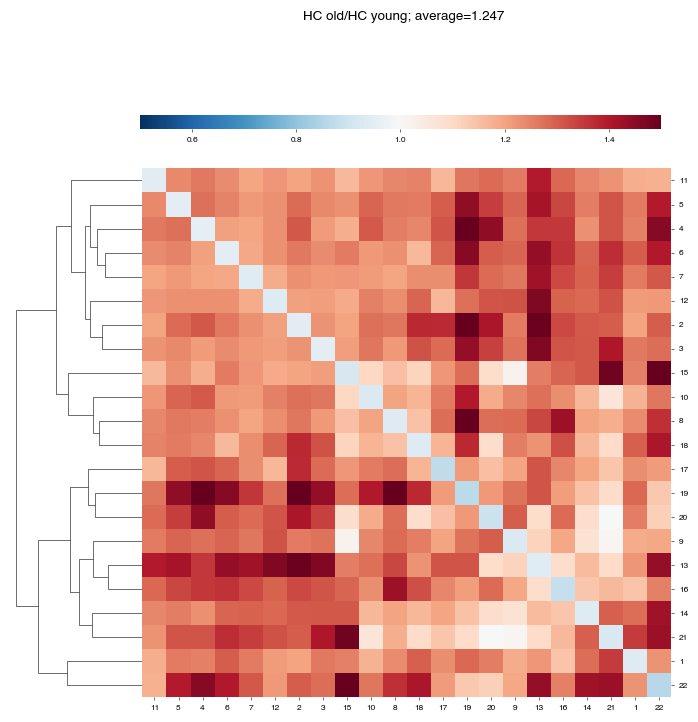

In [19]:
#####HC

selected_keys = ['hc_plus_young.sampled.drop_diag.1kb',
 'hc_plus_old.sampled.drop_diag.1kb']

map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m = map2 / map1
names_samples = []
for i in selected_keys:
    if 'plus' in i:
            names_samples.append(i.split('_')[1].replace("plus", "neurons"))
    if 'minus' in i :
            names_samples.append(i.split('_')[1].replace("minus", "glia"))

df_corr = pd.DataFrame(m)
df_corr.index = chroms[:22]
df_corr.columns = chroms[:22]
df_corr.columns = [i.split("chr")[1] for i in df_corr.columns.tolist()]
df_corr.index =  df_corr.columns.tolist()


g = sns.clustermap(df_corr, figsize = (7,7),
                   cbar_kws={"orientation": "horizontal"},
                   metric="correlation", cmap="RdBu_r", vmax=1.5, vmin=0.5)
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([x0+0.183, 0.85, g.ax_row_dendrogram.get_position().width+0.555, 0.02])

g.fig.suptitle("HC old" + '/' + "HC young" + '; average=%.3f' % np.nanmean(m),  y=1.02, x =0.58)

plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
#plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=1)

sns.set_style("ticks")

g.ax_row_dendrogram.set_visible(True)
g.ax_col_dendrogram.set_visible(False)

# dendro_box = g.ax_row_dendrogram.get_position()
# dendro_box.x0 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# dendro_box.x1 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# g.cax.set_position(dendro_box)
#g.cax.yaxis.set_ticks_position("default")

#plt.tight_layout()

plt.savefig('picture_results/Cistrans_HC_neuron.svg',bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:7.160e-01 U_stat=2.260e+02


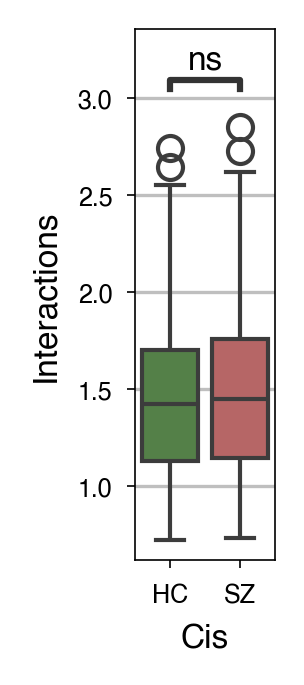

In [47]:
m_hc = interactions50000_new['hc_plus.sampled.drop_diag.1kb'][:-3, :-3]
m_hc_intra = list(np.diag(m_hc))
m_hc_inter = list(m_hc[np.triu_indices_from(m_hc, k=1)])

m_sz = interactions50000_new['sz_plus.sampled.drop_diag.1kb'][:-3, :-3]
m_sz_intra = list(np.diag(m_sz))
m_sz_inter = list(m_sz[np.triu_indices_from(m_sz, k=1)])

df = pd.DataFrame({'Interactions': m_hc_intra + m_sz_intra, ' ': ['HC' for _ in range(len(m_hc_intra))] + ['SZ' for _ in range(len(m_hc_intra))], 'Interaction type': ['Cis' for _ in range(len(m_hc_intra)+len(m_sz_intra))]})
df['stat'] = df[' '] + df['Interaction type']

colormap = {'HC': '#4e893f', 
            'SZ': '#c35959'}

plt.figure(dpi=300, figsize=(0.6,2.3))
box_plot=sns.boxplot(data = df, y = 'Interactions', x = ' ', hue = ' ', palette = colormap)
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
box_plot.legend_ = None
pairs = [('HC', 'SZ')]

annotator = Annotator(box_plot, pairs, data = df, y = 'Interactions', x = ' ')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#plt.tight_layout()
plt.xlabel('Cis')
plt.savefig('picture_results/Cis_neuron.svg',bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:1.222e-01 U_stat=2.890e+04


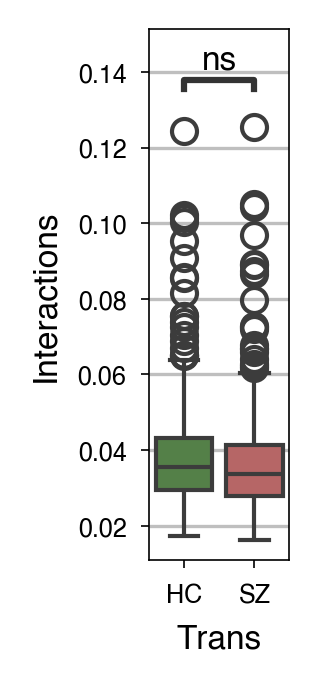

In [48]:
m_hc = interactions50000_new['hc_plus.sampled.drop_diag.1kb'][:-3, :-3]
m_hc_intra = list(np.diag(m_hc))
m_hc_inter = list(m_hc[np.triu_indices_from(m_hc, k=1)])

m_sz = interactions50000_new['sz_plus.sampled.drop_diag.1kb'][:-3, :-3]
m_sz_intra = list(np.diag(m_sz))
m_sz_inter = list(m_sz[np.triu_indices_from(m_sz, k=1)])

df = pd.DataFrame({'Interactions': m_hc_inter + m_sz_inter, ' ': ['HC' for _ in range(len(m_hc_inter))] + ['SZ' for _ in range(len(m_hc_inter))], 'Interaction type': ['Cis' for _ in range(len(m_hc_inter)+len(m_sz_inter))]})
df['stat'] = df[' '] + df['Interaction type']

colormap = {'HC': '#4e893f', 
            'SZ': '#c35959'}

plt.figure(dpi=300, figsize=(0.6,2.3))
box_plot=sns.boxplot(data = df, y = 'Interactions', x = ' ', hue = ' ', palette = colormap)
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
box_plot.legend_ = None
pairs = [('HC', 'SZ')]

annotator = Annotator(box_plot, pairs, data = df, y = 'Interactions', x = ' ')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#plt.tight_layout()
plt.xlabel('Trans')
plt.savefig('picture_results/Trans_neuron.svg',bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Cis vs. Trans: Mann-Whitney-Wilcoxon test two-sided, P_val:5.515e-28 U_stat=0.000e+00


(<Axes: xlabel='Interaction type', ylabel='Interactions'>,
 [<statannotations.Annotation.Annotation at 0x7fab5d448850>])

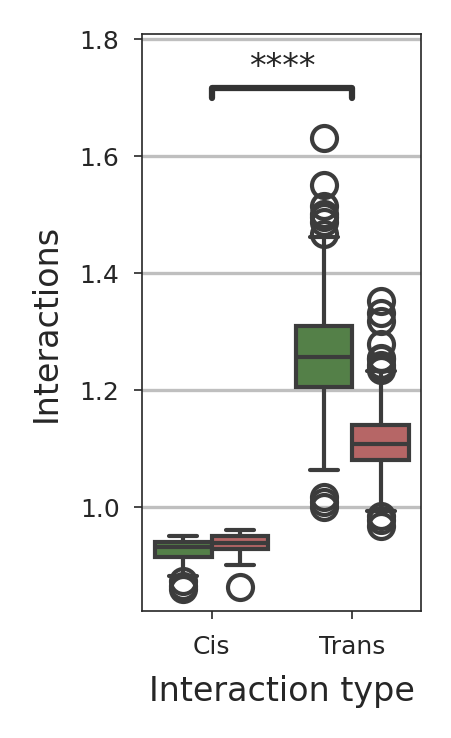

In [41]:
selected_keys = ['hc_plus_young.sampled.drop_diag.1kb',
 'hc_plus_old.sampled.drop_diag.1kb']
map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m_hc = map2 / map1
m_hc_intra = list(np.diag(m_hc))
m_hc_inter = list(m_hc[np.triu_indices_from(m_hc, k=1)])

selected_keys = ['sz_plus_young.sampled.drop_diag.1kb',
 'sz_plus_old.sampled.drop_diag.1kb']
map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m_sz = map2 / map1
m_sz_intra = list(np.diag(m_sz))
m_sz_inter = list(m_sz[np.triu_indices_from(m_sz, k=1)])

df = pd.DataFrame({'Interactions': m_hc_intra + m_sz_intra + m_hc_inter + m_sz_inter, ' ': ['HC o/y' for _ in range(len(m_hc_intra))] + ['SZ o/y' for _ in range(len(m_hc_intra))] + ['HC o/y' for _ in range(len(m_hc_inter))] + ['SZ o/y' for _ in range(len(m_sz_inter))], 'Interaction type': ['Cis' for _ in range(len(m_hc_intra)+len(m_sz_intra))] + ['Trans' for _ in range(len(m_hc_inter)+len(m_sz_inter))]})
df['stat'] = df[' '] + df['Interaction type']

colormap = {'HC o/y': '#4e893f', 
            'SZ o/y': '#c35959'}

plt.figure(dpi=300, figsize=(1.2,2.5))
box_plot=sns.boxplot(data = df, y = 'Interactions', x = 'Interaction type', hue = ' ', palette = colormap)
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
box_plot.legend_ = None
pairs = [('Cis', 'Trans')]

annotator = Annotator(box_plot, pairs, data = df, y = 'Interactions', x = 'Interaction type')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#plt.tight_layout()
#plt.savefig('picture_results/Cis_trans.svg',bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC o/y
Cis vs. SZ o/y
Cis: Mann-Whitney-Wilcoxon test two-sided, P_val:4.476e-02 U_stat=1.560e+02
HC o/y
Trans vs. SZ o/y
Trans: Mann-Whitney-Wilcoxon test two-sided, P_val:5.827e-52 U_stat=4.844e+04


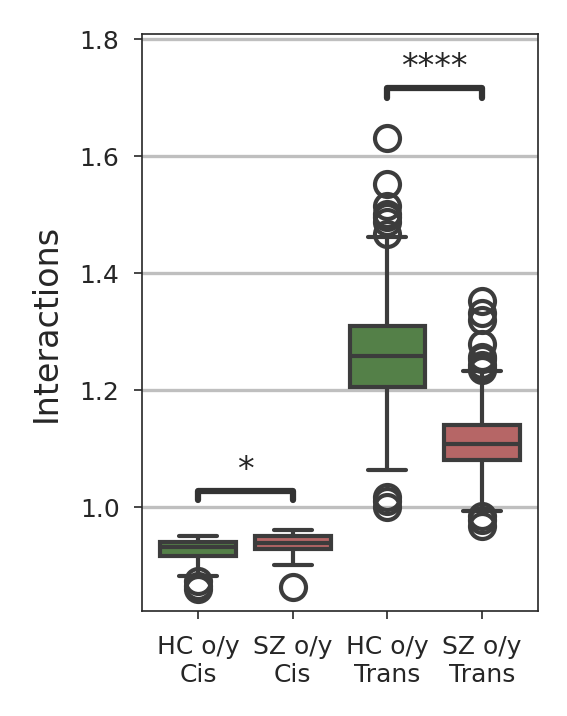

In [57]:
selected_keys = ['hc_plus_young.sampled.drop_diag.1kb',
 'hc_plus_old.sampled.drop_diag.1kb']
map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m_hc = map2 / map1
m_hc_intra = list(np.diag(m_hc))
m_hc_inter = list(m_hc[np.triu_indices_from(m_hc, k=1)])

selected_keys = ['sz_plus_young.sampled.drop_diag.1kb',
 'sz_plus_old.sampled.drop_diag.1kb']
map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m_sz = map2 / map1
m_sz_intra = list(np.diag(m_sz))
m_sz_inter = list(m_sz[np.triu_indices_from(m_sz, k=1)])

df = pd.DataFrame({'Interactions': m_hc_intra + m_sz_intra + m_hc_inter + m_sz_inter, ' ': ['HC o/y' for _ in range(len(m_hc_intra))] + ['SZ o/y' for _ in range(len(m_hc_intra))] + ['HC o/y' for _ in range(len(m_hc_inter))] + ['SZ o/y' for _ in range(len(m_sz_inter))], 'Interaction type': ['Cis' for _ in range(len(m_hc_intra)+len(m_sz_intra))] + ['Trans' for _ in range(len(m_hc_inter)+len(m_sz_inter))]})
df[''] = df[' '] + '\n' + df['Interaction type']

colormap = {'HC o/y': '#4e893f', 
            'SZ o/y': '#c35959'}

plt.figure(dpi=300, figsize=(1.7,2.5))
box_plot=sns.boxplot(data = df, y = 'Interactions', x = '', hue = ' ', palette = colormap)
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
box_plot.legend_ = None
pairs = [('HC o/y\nCis', 'SZ o/y\nCis'), ('HC o/y\nTrans', 'SZ o/y\nTrans')]

annotator = Annotator(box_plot, pairs, data = df, y = 'Interactions', x = '')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

#plt.tight_layout()
plt.savefig('picture_results/Cis_trans_boxplot_neuron.svg',bbox_inches='tight')

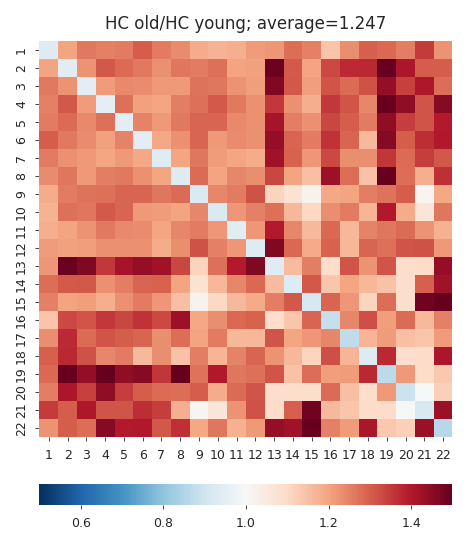

In [90]:
#####HC

selected_keys = ['hc_plus_young.sampled.drop_diag.1kb',
 'hc_plus_old.sampled.drop_diag.1kb']

map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m = map2 / map1
names_samples = []
for i in selected_keys:
    if 'plus' in i:
            names_samples.append(i.split('_')[1].replace("plus", "neurons"))
    if 'minus' in i :
            names_samples.append(i.split('_')[1].replace("minus", "glia"))

df_corr = pd.DataFrame(m)
df_corr.index = chroms[:22]
df_corr.columns = chroms[:22]
df_corr.columns = [i.split("chr")[1] for i in df_corr.columns.tolist()]
df_corr.index =  df_corr.columns.tolist()

f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(3, 3.5), 
                  layout="constrained")

g = sns.heatmap(df_corr, ax = axs, 
                   cbar_kws={"orientation": "horizontal"}, cmap="RdBu_r", vmax=1.5, vmin=0.5)
#x0, _y0, _w, _h = g.cbar_pos
#g.ax_cbar.set_position([x0+0.183, 0.85, g.ax_row_dendrogram.get_position().width+0.555, 0.02])

plt.title(f"HC old/HC young; average={np.nanmean(m):.3f}")

#plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
#plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=1)

sns.set_style("ticks")

#g.ax_row_dendrogram.set_visible(True)
#g.ax_col_dendrogram.set_visible(False)

# dendro_box = g.ax_row_dendrogram.get_position()
# dendro_box.x0 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# dendro_box.x1 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# g.cax.set_position(dendro_box)
#g.cax.yaxis.set_ticks_position("default")

#plt.tight_layout()

plt.savefig('picture_results/Cistrans_HC_neuron.svg',bbox_inches='tight')

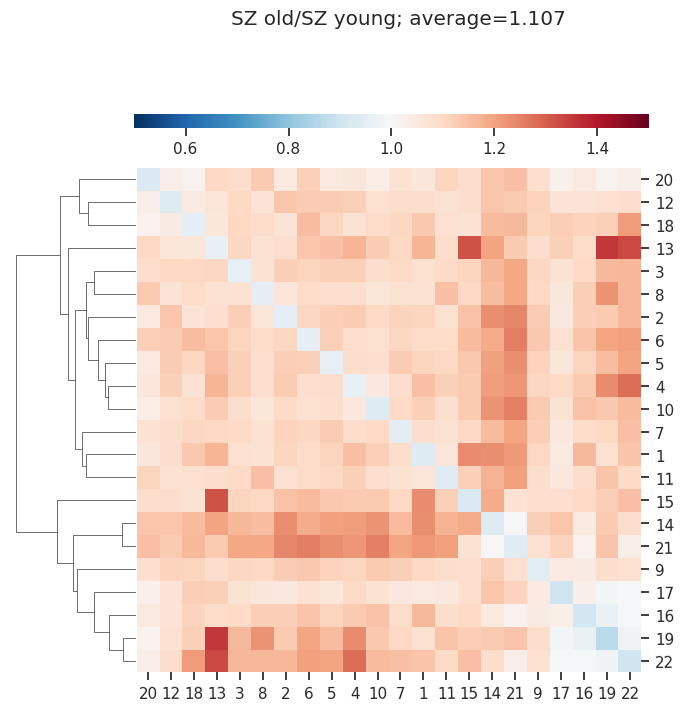

In [83]:
#####HC

selected_keys = ['sz_plus_young.sampled.drop_diag.1kb',
 'sz_plus_old.sampled.drop_diag.1kb']

map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m = map2 / map1
names_samples = []
for i in selected_keys:
    if 'plus' in i:
            names_samples.append(i.split('_')[1].replace("plus", "neurons"))
    if 'minus' in i :
            names_samples.append(i.split('_')[1].replace("minus", "glia"))

df_corr = pd.DataFrame(m)
df_corr.index = chroms[:22]
df_corr.columns = chroms[:22]
df_corr.columns = [i.split("chr")[1] for i in df_corr.columns.tolist()]
df_corr.index =  df_corr.columns.tolist()


g = sns.clustermap(df_corr, figsize = (7,7),
                   cbar_kws={"orientation": "horizontal"},
                   metric="correlation", cmap="RdBu_r", vmax=1.5, vmin=0.5)
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([x0+0.183, 0.85, g.ax_row_dendrogram.get_position().width+0.555, 0.02])

g.fig.suptitle("SZ old" + '/' + "SZ young" + '; average=%.3f' % np.nanmean(m),  y=1.02, x =0.58)

plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=1)

sns.set_style("ticks")

g.ax_row_dendrogram.set_visible(True)
g.ax_col_dendrogram.set_visible(False)

# dendro_box = g.ax_row_dendrogram.get_position()
# dendro_box.x0 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# dendro_box.x1 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# g.cax.set_position(dendro_box)
g.cax.yaxis.set_ticks_position("default")  

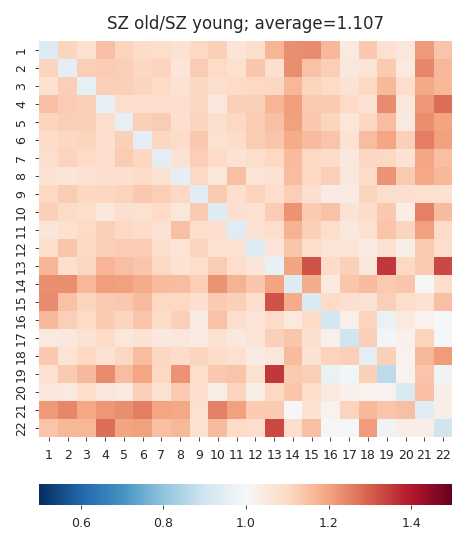

In [91]:
#####HC

selected_keys = ['sz_plus_young.sampled.drop_diag.1kb',
 'sz_plus_old.sampled.drop_diag.1kb']

map1 = interactions50000_new[selected_keys[0]][:-3, :-3] # -1 is for ignoring of the last chromosome
map2 = interactions50000_new[selected_keys[1]][:-3, :-3]
m = map2 / map1
names_samples = []
for i in selected_keys:
    if 'plus' in i:
            names_samples.append(i.split('_')[1].replace("plus", "neurons"))
    if 'minus' in i :
            names_samples.append(i.split('_')[1].replace("minus", "glia"))

df_corr = pd.DataFrame(m)
df_corr.index = chroms[:22]
df_corr.columns = chroms[:22]
df_corr.columns = [i.split("chr")[1] for i in df_corr.columns.tolist()]
df_corr.index =  df_corr.columns.tolist()

f, axs = plt.subplots(1, 1, dpi=150, sharex=True, 
                  figsize=(3, 3.5), 
                  layout="constrained")

g = sns.heatmap(df_corr, ax = axs, 
                   cbar_kws={"orientation": "horizontal"}, cmap="RdBu_r", vmax=1.5, vmin=0.5)
#x0, _y0, _w, _h = g.cbar_pos
#g.ax_cbar.set_position([x0+0.183, 0.85, g.ax_row_dendrogram.get_position().width+0.555, 0.02])

plt.title(f"SZ old/SZ young; average={np.nanmean(m):.3f}")

#plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
#plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=1)

sns.set_style("ticks")

#g.ax_row_dendrogram.set_visible(True)
#g.ax_col_dendrogram.set_visible(False)

# dendro_box = g.ax_row_dendrogram.get_position()
# dendro_box.x0 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# dendro_box.x1 = (dendro_box.x0 + 2 * dendro_box.x1) / 3
# g.cax.set_position(dendro_box)
#g.cax.yaxis.set_ticks_position("default")

#plt.tight_layout()

plt.savefig('picture_results/Cistrans_SZ_neuron.svg',bbox_inches='tight')

## Polycomb

In [16]:
pcg = pd.read_csv('../data/polycomb_dot_anchors.5kb.16_06_25.csv')
pcg

,chrom,start,end,genes
0,chr1,18630000,18640000,PAX7
1,chr1,24930000,24940000,RUNX3
2,chr1,44410000,44420000,RNF220
3,chr1,46480000,46490000,NaN
4,chr1,47180000,47250000,"TAL1,AL135960.1"
...,...,...,...,...
257,chr2,181680000,181690000,"CERKL,NEUROD1"
258,chr2,218990000,219000000,CRYBA2
259,chr4,80260000,80270000,FGF5
260,chr10,92680000,92690000,HHEX


In [17]:
clr_dir = '../data/'
clr_names = {
            'HC-2Mplus': 'HC-2Mplus.sampled.drop_diag.1kb.mcool',
            'HC24plus': 'HC24plus.sampled.drop_diag.1kb.mcool',
            'HC-91plus': 'HC-91plus.sampled.drop_diag.1kb.mcool',
            'HC-318plus': 'HC-318plus.sampled.drop_diag.1kb.mcool',
            'HCM12plus': 'HCM12plus.sampled.drop_diag.1kb.mcool',
            'HC-3Mplus': 'HC-3Mplus.sampled.drop_diag.1kb.mcool',

            'SZ-01plus': 'SZ-01plus.sampled.drop_diag.1kb.mcool',
            'SZ-03plus': 'SZ-03plus.sampled.drop_diag.1kb.mcool',
            'SZ6plus': 'SZ6plus.sampled.drop_diag.1kb.mcool',
            'SZ08plus': 'SZ08plus.sampled.drop_diag.1kb.mcool',
            'SZ10plus': 'SZ10plus.sampled.drop_diag.1kb.mcool',
            'SZ20plus': 'SZ20plus.sampled.drop_diag.1kb.mcool',
}

res_10 = 10_000
clrs_10 = {name: cooler.Cooler(f'{clr_dir}/' + clr_names[name] + f'::resolutions/{res_10}') for name in clr_names.keys()}

# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bf.fetch_chromsizes('hg38')
hg38_chromsizes_view = pd.DataFrame(data={'chrom': hg38_chromsizes.index, 
                                          'start': 0*len(hg38_chromsizes),
                                          'end': hg38_chromsizes.values,
                                          'name': hg38_chromsizes.index})
hg38_chromsizes_view.head()

cts = ['HCM12plus', 'HC-3Mplus', 'HC24plus', 'HC-318plus', 'HC-91plus', 'HC-2Mplus',
       'SZ-01plus', 'SZ20plus', 'SZ10plus', 'SZ08plus', 'SZ-03plus', 'SZ6plus']


# CIS expected
cvd_10 = {}

for ct in cts:
    #print(ct)
    cvd_10[ct] = expected_cis_cache(
        clrs_10[ct],
        smooth=False,
        nproc=10
    )

# TRANS expected
trans_cvd_10 = {}

for ct in cts:
    #print(ct)
    trans_cvd_10[ct] = expected_trans_cache(
        clrs_10[ct],
        nproc=10
    )

dot_anch = pd.read_csv('../data/polycomb_dot_anchors.5kb.16_06_25.csv')

dot_anch.loc[:, 'mid_start'] = (dot_anch['start'] + dot_anch['end']) / 2 \
    - ((dot_anch['start'] + dot_anch['end']) / 2) % res_10
dot_anch.loc[:, 'mid_end'] = dot_anch['mid_start'] + res_10
dot_anch.loc[:, 'mid_start'] = dot_anch.loc[:, 'mid_start'].astype(int)
dot_anch.loc[:, 'mid_end'] = dot_anch.loc[:, 'mid_end'].astype(int)
dot_anch.head()


,chrom,start,end,genes,mid_start,mid_end
0,chr1,18630000,18640000,PAX7,18630000.0,18640000.0
1,chr1,24930000,24940000,RUNX3,24930000.0,24940000.0
2,chr1,44410000,44420000,RNF220,44410000.0,44420000.0
3,chr1,46480000,46490000,NaN,46480000.0,46490000.0
4,chr1,47180000,47250000,"TAL1,AL135960.1",47210000.0,47220000.0


In [18]:
# Split by distance
nproc=10
pup_hand = {ct: {} for ct in cts}

for ct in cts:
    print(ct)
    pup_hand[ct]['short'] = coolpup_pileup_cache(
        clrs_10[ct], 
        dot_anch,
        expected_df=cvd_10[ct],
        flank=150000,
        mindist=3*res_10,
        maxdist=int(3e6),
        nproc=nproc
    );
    pup_hand[ct]['long'] = coolpup_pileup_cache(
        clrs_10[ct], 
        dot_anch,
        expected_df=cvd_10[ct],
        flank=150000,
        mindist=int(3e6),
        nproc=nproc
    );
    pup_hand[ct]['trans'] = coolpup_pileup_cache(
        clrs_10[ct], 
        dot_anch,
        expected_df=trans_cvd_10[ct],
        flank=150000,
        trans=True,
        nproc=nproc
    );

HCM12plus
HC-3Mplus
HC24plus
HC-318plus
HC-91plus
HC-2Mplus
SZ-01plus
SZ20plus
SZ10plus
SZ08plus
SZ-03plus
SZ6plus


Text(0.5, 0, 'Distance from\nH3K27me3 peak')

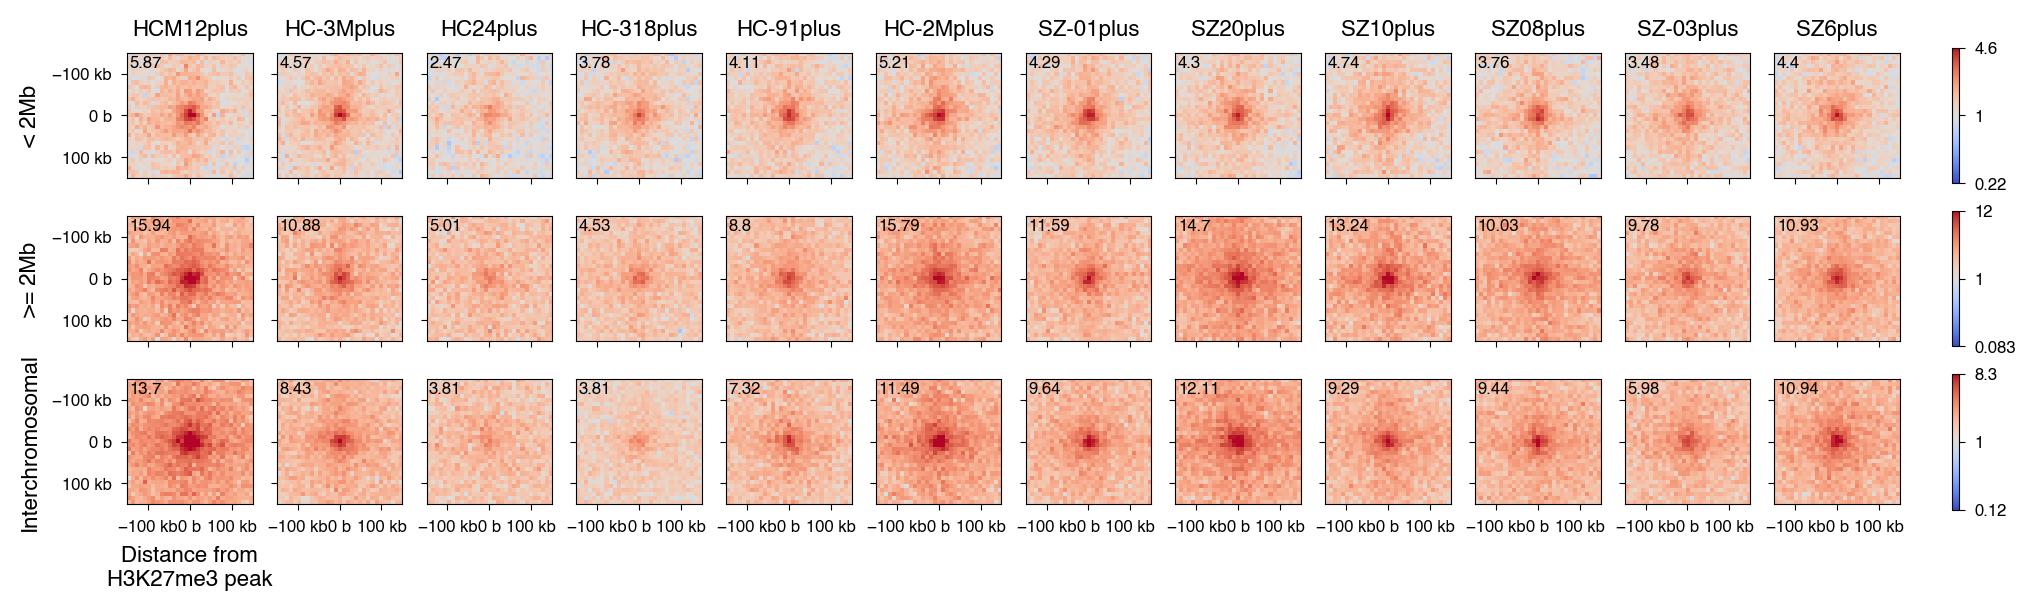

In [19]:
# Plot data for each ct separately
bp_formatter = EngFormatter('b')


def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1e5))
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1e5))
        ax.xaxis.tick_bottom()
        
        
nrows, ncols = 3, len(cts)
fig, axs = plt.subplots(nrows, ncols+1, dpi=200, figsize=(len(cts), 3),
                        gridspec_kw={'width_ratios': [1] * ncols + [0.5]})

vmax = {'short': 4.6, 'long': 12, 'trans': 8.3}
vmin = {k: 1/val for k, val in vmax.items()}
pup_grps = ['short', 'long', 'trans']

for i, pup in enumerate(pup_grps):
    for j, ct in enumerate(cts):
        arr = pup_hand[ct][pup]['data'][0]
        im = axs[i, j].imshow(
            arr, 
            cmap='coolwarm',
            norm=LogNorm(vmax=vmax[pup], vmin=vmin[pup]),
            extent=(-150000, 150000, 150000, -150000)
        )
        # Enrichment
        en = get_enrichment(arr, 0)
        axs[i, j].text(0.02, 0.98, round(en, 2), va='top', 
                       transform=axs[i, j].transAxes, fontsize=6)
        format_ticks(axs[i, j])
    
    # Colorbar
    plt.colorbar(im, cax=axs[i, ncols], ticks=[vmin[pup], 1, vmax[pup]], 
                 format=ticker.FuncFormatter(lambda x, pos: f"{x:.2g}"))
    axs[i, ncols].set_box_aspect(20)
    axs[i, ncols].minorticks_off()

# Ticks
#for i in range(3):
for i, j in product(range(3), range(1, ncols)):
    axs[i, j].yaxis.set_ticklabels([])
for i, j in product([0, 1], range(0, ncols)):
    axs[i, j].xaxis.set_ticklabels([])
    
# Labels

for i in range(len(cts)):
    axs[0, i].set_title(cts[i])

axs[0, 0].set_ylabel('< 2Mb')
axs[1, 0].set_ylabel('>= 2Mb')
axs[2, 0].set_ylabel('Interchromosomal')
axs[2, 0].set_xlabel('Distance from\nH3K27me3 peak')

In [20]:
cts_mean = ['hc_young', 'hc_old', 'sz_young', 'sz_old']
pup_mean = {ct: {} for ct in cts_mean}
for i, pup in enumerate(pup_grps):
    pup_mean['hc_young'][pup] = np.mean([pup_hand['HCM12plus'][pup]['data'][0], pup_hand['HC-3Mplus'][pup]['data'][0]], axis = 0)
    pup_mean['hc_old'][pup] = np.mean([pup_hand['HC-91plus'][pup]['data'][0], pup_hand['HC-2Mplus'][pup]['data'][0], pup_hand['HC24plus'][pup]['data'][0], pup_hand['HC-318plus'][pup]['data'][0]], axis = 0)
    pup_mean['sz_young'][pup] = np.mean([pup_hand['SZ-01plus'][pup]['data'][0], pup_hand['SZ20plus'][pup]['data'][0]], axis = 0)
    pup_mean['sz_old'][pup] = np.mean([pup_hand['SZ10plus'][pup]['data'][0], pup_hand['SZ08plus'][pup]['data'][0], pup_hand['SZ-03plus'][pup]['data'][0], pup_hand['SZ6plus'][pup]['data'][0]], axis = 0)


Text(0.5, 0, 'Distance from\nH3K27me3 peak')

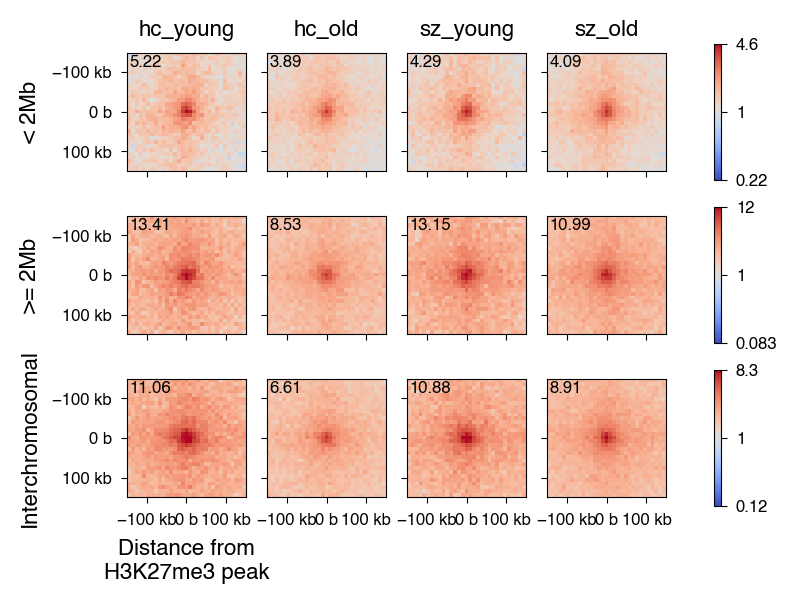

In [21]:
# Plot data for each ct separately
bp_formatter = EngFormatter('b')


def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1e5))
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1e5))
        ax.xaxis.tick_bottom()
        
        
nrows, ncols = 3, len(cts_mean)
fig, axs = plt.subplots(nrows, ncols+1, dpi=200, figsize=(len(cts_mean), 3),
                        gridspec_kw={'width_ratios': [1] * ncols + [0.5]})

vmax = {'short': 4.6, 'long': 12, 'trans': 8.3}
vmin = {k: 1/val for k, val in vmax.items()}
pup_grps = ['short', 'long', 'trans']

for i, pup in enumerate(pup_grps):
    for j, ct in enumerate(cts_mean):
        arr = pup_mean[ct][pup]
        im = axs[i, j].imshow(
            arr, 
            cmap='coolwarm',
            norm=LogNorm(vmax=vmax[pup], vmin=vmin[pup]),
            extent=(-150000, 150000, 150000, -150000)
        )
        # Enrichment
        en = get_enrichment(arr, 0)
        axs[i, j].text(0.02, 0.98, round(en, 2), va='top', 
                       transform=axs[i, j].transAxes, fontsize=6)
        format_ticks(axs[i, j])
    
    # Colorbar
    plt.colorbar(im, cax=axs[i, ncols], ticks=[vmin[pup], 1, vmax[pup]], 
                 format=ticker.FuncFormatter(lambda x, pos: f"{x:.2g}"))
    axs[i, ncols].set_box_aspect(20)
    axs[i, ncols].minorticks_off()

# Ticks
for i, j in product(range(3), range(1, ncols)):
    axs[i, j].yaxis.set_ticklabels([])
for i, j in product([0, 1], range(0, ncols)):
    axs[i, j].xaxis.set_ticklabels([])
    
# Labels

for i in range(len(cts_mean)):
    axs[0, i].set_title(cts_mean[i])

axs[0, 0].set_ylabel('< 2Mb')
axs[1, 0].set_ylabel('>= 2Mb')
axs[2, 0].set_ylabel('Interchromosomal')
axs[2, 0].set_xlabel('Distance from\nH3K27me3 peak')

Text(0.5, 0, 'Distance from\nH3K27me3 peak')

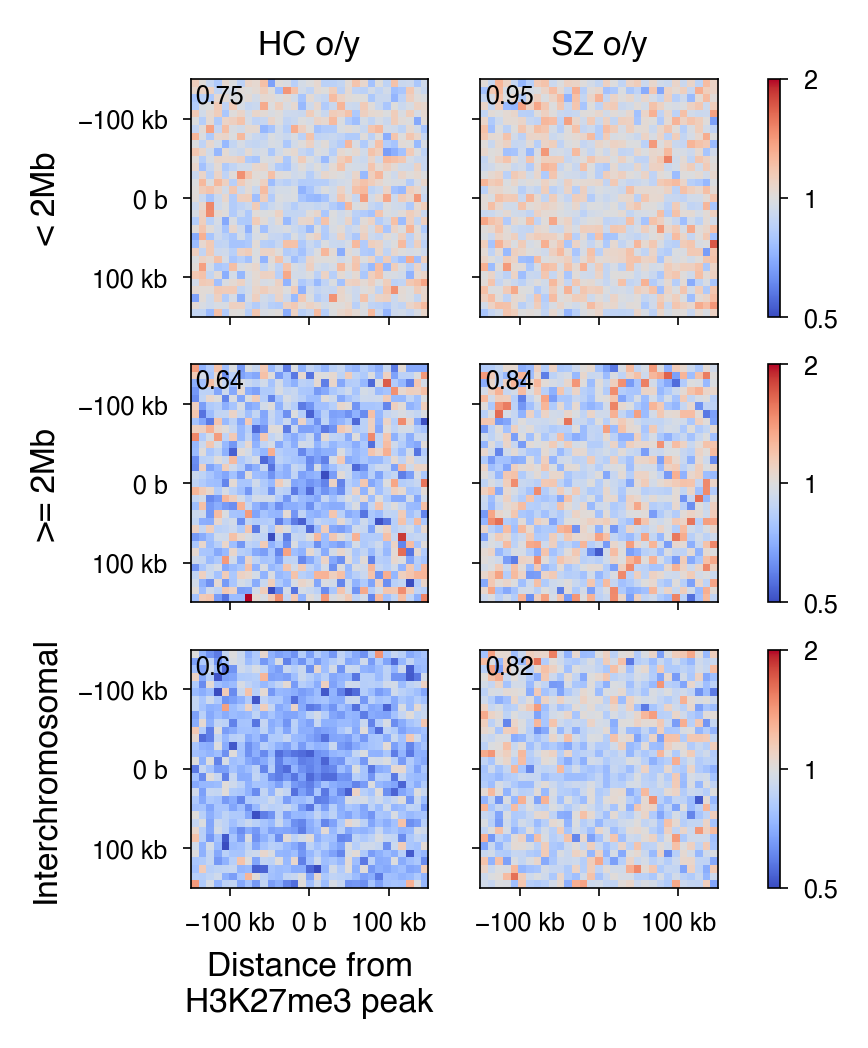

In [28]:
cts_mean_rat = ['HC o/y', 'SZ o/y']
pup_mean_rat = {ct: {} for ct in cts_mean_rat}
for i, pup in enumerate(pup_grps):
    pup_mean_rat['HC o/y'][pup] = pup_mean['hc_old'][pup]/ pup_mean['hc_young'][pup]
    pup_mean_rat['SZ o/y'][pup] = pup_mean['sz_old'][pup]/ pup_mean['sz_young'][pup]


# Plot data for each ct separately
bp_formatter = EngFormatter('b')


def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1e5))
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1e5))
        ax.xaxis.tick_bottom()
        
        
nrows, ncols = 3, len(cts_mean_rat)
fig, axs = plt.subplots(nrows, ncols+1, dpi=300, figsize=(len(cts_mean_rat)+0.6, 3.5),
                        gridspec_kw={'width_ratios': [1] * ncols + [0.1]})

vmax = {'short': 2, 'long': 2, 'trans': 2}
vmin = {k: 1/val for k, val in vmax.items()}
pup_grps = ['short', 'long', 'trans']

for i, pup in enumerate(pup_grps):
    for j, ct in enumerate(cts_mean_rat):
        arr = pup_mean_rat[ct][pup]
        im = axs[i, j].imshow(
            arr, 
            cmap='coolwarm',
            norm=LogNorm(vmax=vmax[pup], vmin=vmin[pup]),
            extent=(-150000, 150000, 150000, -150000)
        )
        #Enrichment
        en = get_enrichment(arr, 0)
        axs[i, j].text(0.02, 0.98, round(en, 2), va='top', 
                       transform=axs[i, j].transAxes, fontsize=6)
        format_ticks(axs[i, j])
    
    # Colorbar
    plt.colorbar(im, cax=axs[i, ncols], ticks=[vmin[pup], 1, vmax[pup]], 
                 format=ticker.FuncFormatter(lambda x, pos: f"{x:.2g}"))
    axs[i, ncols].set_box_aspect(20)
    axs[i, ncols].minorticks_off()

# Ticks
for i in range(3):
    axs[i, 1].yaxis.set_ticklabels([])
for i, j in [[0, 0], [0, 1], [1, 0], [1, 1]]:
    axs[i, j].xaxis.set_ticklabels([])
    
# Labels

for i in range(len(cts_mean_rat)):
    axs[0, i].set_title(cts_mean_rat[i])

axs[0, 0].set_ylabel('< 2Mb')
axs[1, 0].set_ylabel('>= 2Mb')
axs[2, 0].set_ylabel('Interchromosomal')
axs[2, 0].set_xlabel('Distance from\nH3K27me3 peak')

plt.savefig('picture_results/Polycomb.svg',bbox_inches='tight')